In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   -- ------------------------------------ 20.5/307.2 kB 640.0 kB/s eta 0:00:01
   -------------- ------------------------- 112.6/307.2 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 307.2/307.2 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd

df = pd.read_csv("../data/Tweets.csv")

print(df.head())
print(df.shape)

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

In [15]:
df.isnull().sum()

df.dropna(subset=['text'], inplace=True)

In [17]:
import re
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhadr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [19]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [word for word in words
             if word not in stop_words]

    return " ".join(words)

In [21]:
df['clean_text'] = df['text'].apply(clean_text)

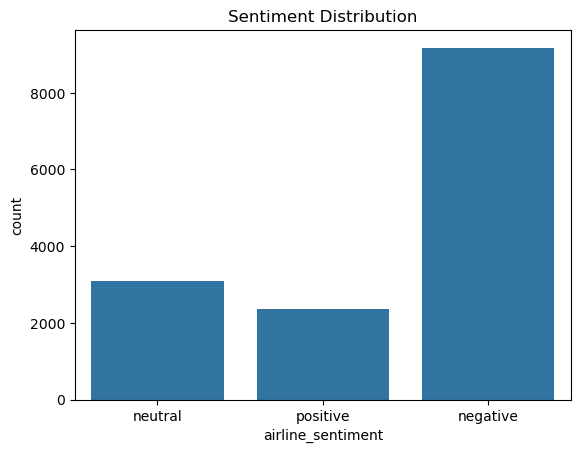

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='airline_sentiment',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

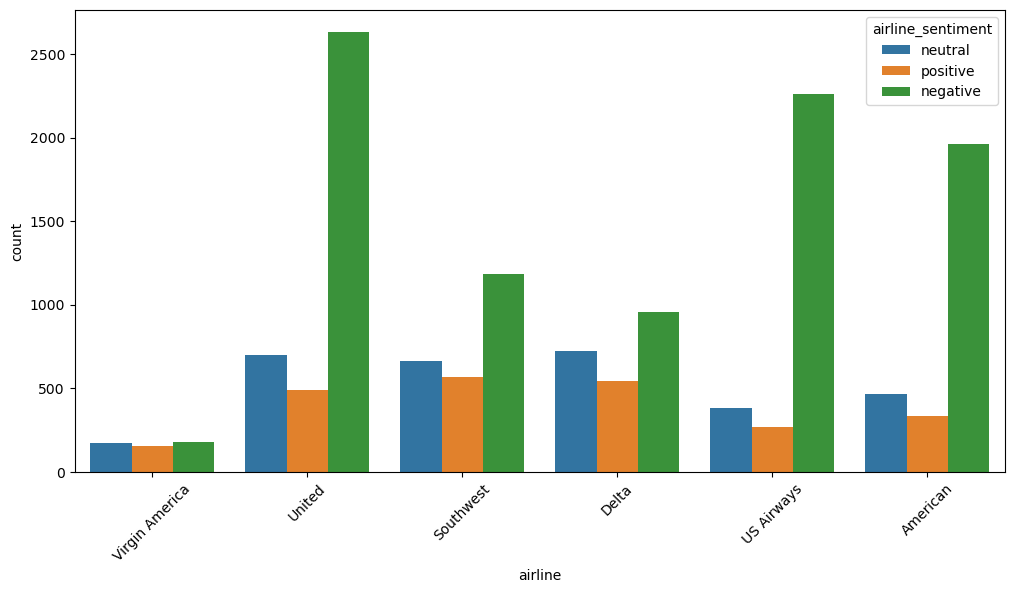

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='airline',
    hue='airline_sentiment',
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)

X = vectorizer.fit_transform(
    df['clean_text']
)

In [29]:
y = df['airline_sentiment']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [35]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [51]:
from sklearn.metrics import accuracy_score

pred_lr = lr.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_lr
    )
)

0.7984972677595629


In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.67      0.48      0.56       580
    positive       0.83      0.61      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



In [57]:
print("Logistic Regression:", lr.score(X_test, y_test))
print("Naive Bayes:", nb.score(X_test, y_test))
print("Random Forest:", rf.score(X_test, y_test))

Logistic Regression: 0.7984972677595629
Naive Bayes: 0.7377049180327869
Random Forest: 0.7728825136612022


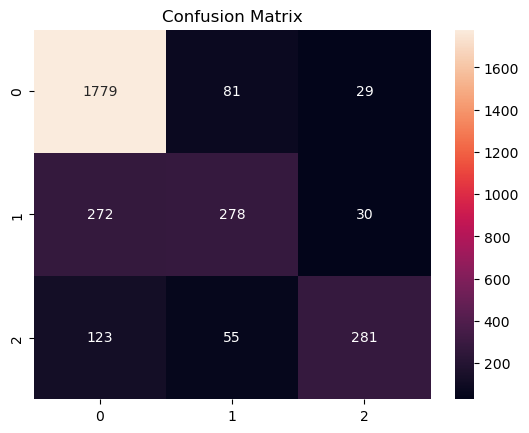

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

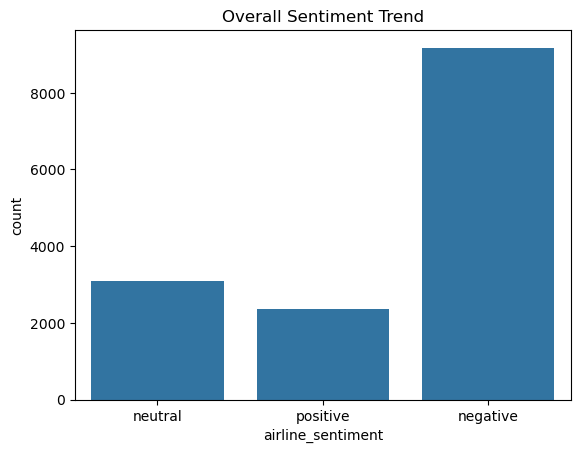

In [45]:
sns.countplot(
    x='airline_sentiment',
    data=df
)

plt.title(
    "Overall Sentiment Trend"
)

plt.show()

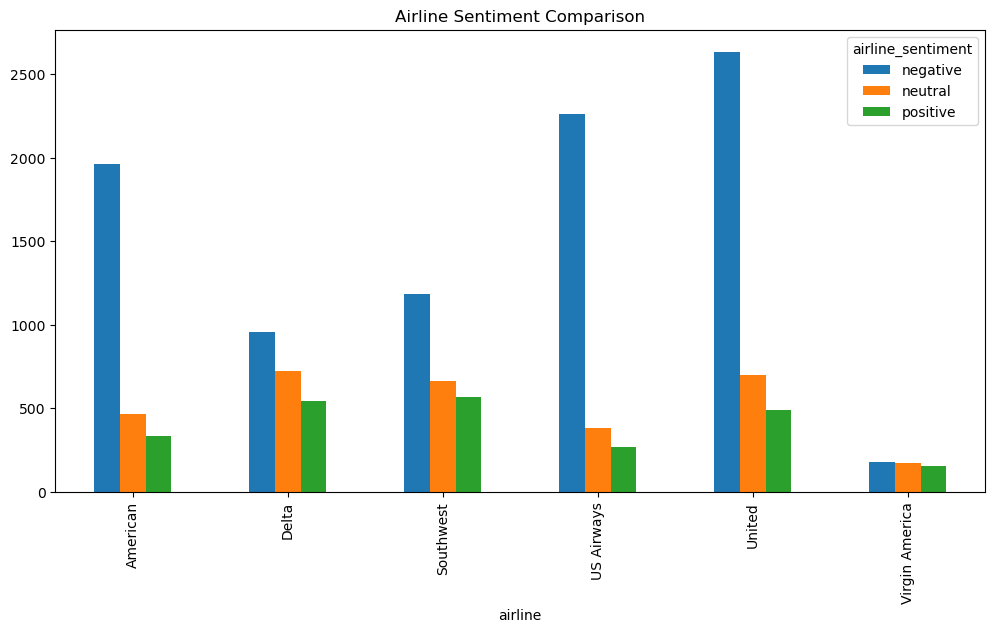

In [47]:
sentiment_counts = pd.crosstab(
    df['airline'],
    df['airline_sentiment']
)

sentiment_counts.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Airline Sentiment Comparison"
)

plt.show()

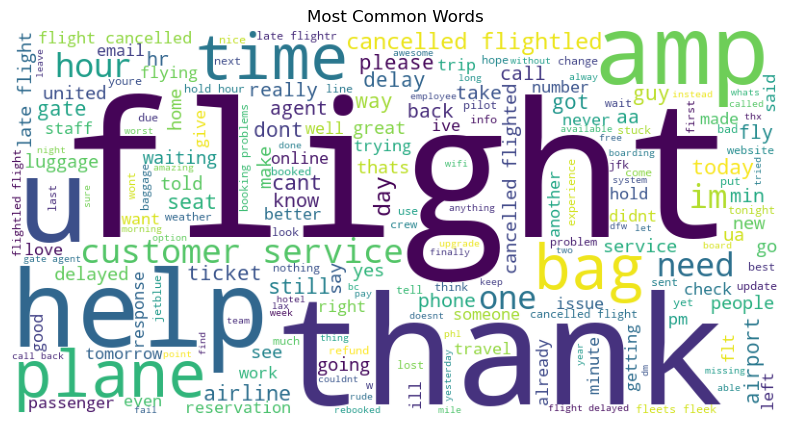

In [59]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Common Words")
plt.show()

In [61]:
import pickle

pickle.dump(
    lr,
    open("sentiment_model.pkl", "wb")
)

pickle.dump(
    vectorizer,
    open("vectorizer.pkl", "wb")
)

In [49]:
review = input(
    "Enter Review: "
)

review_clean = clean_text(
    review
)

review_vector = vectorizer.transform(
    [review_clean]
)

prediction = lr.predict(
    review_vector
)

print(
    "Sentiment:",
    prediction[0]
)

Enter Review:  The flight was delayed and staff were rude


Sentiment: negative
